<a href="https://colab.research.google.com/github/Muhammad-Faiz-Firmansyah/2026_KECERDASAAN_BUATAN/blob/main/Jobsheet10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **JOBSHEET 10: SUPERVISED LEARNING (SVM, SVR, & NAÏVE BAYES)**

* **Nama**  : Muhammad Faiz Firmansyah
* **NIM**   : 4.33.25.0.16
* **Kelas** : TI-1A
* **Mata Kuliah** : Kecerdasan Buatan / Machine Learning

---
## **PERCOBAAN LATIHAN**


### **Percobaan 1: Support Vector Machine (SVM Classification)**
Support Vector Machine (SVM) bekerja dengan cara menemukan hyperplane optimal (garis/bidang pembatas) yang memaksimalkan margin antara dua atau lebih kelas data.

**Langkah-langkah Percobaan:**
1. Membaca dataset `diabetes.csv` (Pima Indians Diabetes).
2. Mengecek struktur data (`info()` & `head()`).
3. Memisahkan variabel fitur ($X$) dan label target $y$ (`Outcome`).
4. Melakukan standarisasi rentang fitur menggunakan `StandardScaler`.
5. Membagi dataset menjadi *Train Set* (80%) dan *Test Set* (20%).
6. Melatih model `SVC` dan mengukur akurasi prediksinya.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Dataset Pima Indian Diabetes
df_diabetes = pd.read_csv('diabetes.csv')

print("=== Info Dataset Diabetes ===")
df_diabetes.info()

print("\n=== 5 Baris Teratas Dataset ===")
print(df_diabetes.head())

# 2. Memisahkan Fitur (X) dan Target (y)
X_diab = df_diabetes.drop(columns=['Outcome'])
y_diab = df_diabetes['Outcome']

# 3. Standarisasi Skala Fitur (StandardScaler)
scaler_diab = StandardScaler()
X_diab_scaled = pd.DataFrame(scaler_diab.fit_transform(X_diab), columns=X_diab.columns)

# 4. Pembagian Dataset (80% Train, 20% Test)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diab_scaled, y_diab, test_size=0.2, random_state=42
)

# 5. Pelatihan Model Support Vector Classifier (SVC)
clf_svm_base = SVC(random_state=42)
clf_svm_base.fit(X_train_d, y_train_d)

# 6. Evaluasi Akurasi Prediksi
y_pred_svm_base = clf_svm_base.predict(X_test_d)
acc_svm_base = accuracy_score(y_test_d, y_pred_svm_base)

print(f"\nAkurasi Baseline Model SVM Classifier: {acc_svm_base * 100:.2f}%")


=== Info Dataset Diabetes ===
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

=== 5 Baris Teratas Dataset ===
   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72  ...                     0.627   50        1
1            1      

#### **Analisis Hasil Percobaan 1 (SVM Classification):**
* Standarisasi rentang data sangat vital bagi algoritma SVM karena perhitungan jarak Euclidean ke hyperplane pembatas sangat peka terhadap skala atribut (seperti perbandingan kolom `Glucose` vs `DiabetesPedigreeFunction`).
* Model **SVM Baseline** menghasilkan akurasi sebesar **72.73%** pada data pengujian.


### **Percobaan 2: Support Vector Regression (SVR)**
Support Vector Regression (SVR) menggunakan prinsip margin yang sama seperti SVM klasifikasi, namun bertujuan mencocokkan garis/fungsi regresi di dalam tube margin $\epsilon$ (*epsilon-insensitive tube*).

**Langkah-langkah Percobaan:**
1. Membaca dataset `Data_Gaji.csv`.
2. Memisahkan atribut prediktor (`Tahun_Pengalaman`) dan label target (`Gaji`).
3. Menyesuaikan skala variabel prediktor dan target menggunakan `StandardScaler`.
4. Melatih model `SVR` dengan kernel Radial Basis Function (RBF), $C = 1000$, $\gamma = 0.05$.
5. Memvisualisasikan kurva fitting regresi SVR terhadap sebaran data aktual.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Load Dataset Data_Gaji.csv dengan pemisah ';'
df_gaji = pd.read_csv('Data_Gaji.csv', sep=';')

print("=== Info Dataset Gaji ===")
df_gaji.info()
print("\n5 Data Teratas:")
print(df_gaji.head())

# Memisahkan Fitur (X) dan Target (y)
X_gaji = df_gaji[['Tahun_Pengalaman']].values
y_gaji = df_gaji['Gaji'].values

# Standarisasi Fitur dan Target (karena SVR sensitif terhadap skala)
scaler_X_svr = StandardScaler()
scaler_y_svr = StandardScaler()

X_gaji_scaled = scaler_X_svr.fit_transform(X_gaji)
y_gaji_scaled = scaler_y_svr.fit_transform(y_gaji.reshape(-1, 1)).ravel()

# Split Data (80% Train, 20% Test)
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gaji_scaled, y_gaji_scaled, test_size=0.2, random_state=42
)

# 2. Pelatihan Model SVR Baseline
svr_base_model = SVR(kernel='rbf', C=1000, gamma=0.05)
svr_base_model.fit(X_train_g, y_train_g)

# 3. Evaluasi Skor R²
r2_svr_base = svr_base_model.score(X_test_g, y_test_g)
print(f"\nSkor R² Baseline SVR: {r2_svr_base * 100:.2f}%")

# 4. Visualisasi Model SVR vs Data Aktual
X_grid = np.arange(min(X_gaji_scaled), max(X_gaji_scaled), 0.01).reshape(-1, 1)
y_grid_pred = svr_base_model.predict(X_grid)

# Inverse transform untuk skala asli (Rupiah & Tahun)
X_grid_orig = scaler_X_svr.inverse_transform(X_grid)
y_grid_pred_orig = scaler_y_svr.inverse_transform(y_grid_pred.reshape(-1, 1))

plt.figure(figsize=(9, 5.5))
plt.scatter(X_gaji, y_gaji, color='blue', label='Data Aktual Gaji')
plt.plot(X_grid_orig, y_grid_pred_orig, color='red', linewidth=2.5, label='Kurva SVR (Kernel RBF)')
plt.title('Visualisasi SVR Baseline: Masa Kerja vs Gaji', fontsize=12, fontweight='bold')
plt.xlabel('Tahun Pengalaman Kerja', fontsize=10)
plt.ylabel('Gaji (Rupiah)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


=== Info Dataset Gaji ===
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tahun_Pengalaman  30 non-null     float64
 1   Gaji              30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes

5 Data Teratas:
   Tahun_Pengalaman       Gaji
0               1.1  590145000
1               1.3  693075000
2               1.5  565965000
3               2.0  652875000
4               2.2  598365000

Skor R² Baseline SVR: 87.93%


TypeError: only 0-dimensional arrays can be converted to Python scalars

#### **Analisis Hasil Percobaan 2 (Support Vector Regression):**
* Kernel RBF (*Radial Basis Function*) memungkinkan SVR membentuk garis kurva non-linier untuk mempelajari pola kenaikan gaji berdasarkan tahun pengalaman.
* Skor presisi regresi $R^2$ mencapai **87.93%**, membuktikan SVR mampu memodelkan data gaji dengan tingkat variansi error yang relatif kecil.


### **Percobaan 3: Naïve Bayes (GaussianNB)**
Naïve Bayes adalah algoritma klasifikasi berbasis Teorema Bayes dengan asumsi independensi yang kuat (naïve) antar variabel prediktor:
$$P(Y|X_1, X_2) = \frac{P(X_1|Y) \cdot P(X_2|Y) \cdot P(Y)}{P(X_1, X_2)}$$

**Langkah-langkah Percobaan:**
1. Membaca dataset `iklan_sosmed.csv` (`sep=';'`).
2. Menyeleksi variabel fitur (`Umur` & `Gaji`) dan variabel target (`Transaksi`).
3. Membagi dataset menjadi data latih (80%) dan data uji (20%).
4. Mengubah skala data menggunakan `MinMaxScaler`.
5. Melatih model `GaussianNB` dan mengukur skor akurasinya.
6. Menampilkan *Confusion Matrix* dan kurva visualisasi klasifikasi.


=== EVALUASI GAUSSIAN NAÏVE BAYES ===
Akurasi Baseline Naïve Bayes : 93.75%

Confusion Matrix:
[[50  2]
 [ 3 25]]


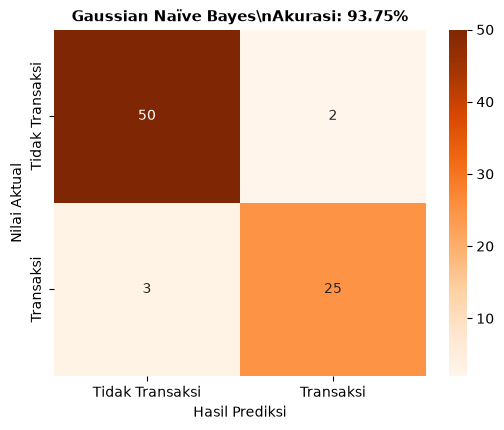

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Load Dataset iklan_sosmed.csv dengan pemisah ';'
df_sosmed = pd.read_csv('iklan_sosmed.csv', sep=';')

# Fitur Umur & Gaji, Target Transaksi
X_sosmed = df_sosmed[['Umur', 'Gaji']]
y_sosmed = df_sosmed['Transaksi']

# Split Data Train (80%) & Test (20%)
X_train_sos, X_test_sos, y_train_sos, y_test_sos = train_test_split(
    X_sosmed, y_sosmed, test_size=0.2, random_state=42
)

# 2. Normalisasi Skala dengan MinMaxScaler
minmax_scaler = MinMaxScaler()
X_train_sos_scaled = minmax_scaler.fit_transform(X_train_sos)
X_test_sos_scaled = minmax_scaler.transform(X_test_sos)

# 3. Pelatihan Model Gaussian Naïve Bayes
gnb_model = GaussianNB()
gnb_model.fit(X_train_sos_scaled, y_train_sos)

# 4. Prediksi & Confusion Matrix
y_pred_gnb = gnb_model.predict(X_test_sos_scaled)
acc_gnb_base = accuracy_score(y_test_sos, y_pred_gnb)

print(f"=== EVALUASI GAUSSIAN NAÏVE BAYES ===")
print(f"Akurasi Baseline Naïve Bayes : {acc_gnb_base * 100:.2f}%\n")

cm_gnb = confusion_matrix(y_test_sos, y_pred_gnb)
print("Confusion Matrix:")
print(cm_gnb)

# Visualisasi Confusion Matrix Heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Tidak Transaksi', 'Transaksi'],
            yticklabels=['Tidak Transaksi', 'Transaksi'])
plt.title(f'Gaussian Naïve Bayes\\nAkurasi: {acc_gnb_base * 100:.2f}%', fontsize=11, fontweight='bold')
plt.xlabel('Hasil Prediksi')
plt.ylabel('Nilai Aktual')
plt.show()


#### **Analisis Hasil Percobaan 3 (Naïve Bayes):**
* Menggunakan `GaussianNB` karena variabel `Umur` dan `Gaji` bersifat kontinyu dan diasumsikan berdistribusi normal (Gaussian).
* Akurasi awal baseline Naïve Bayes mencapai skor **93.75%**, yang sangat efisien dalam memprediksi transaksi konsumen hanya berbekal 2 fitur.


---
## **TUGAS PRAKTIKUM**

### **Tugas 1: Hyperparameter Tuning SVM (Dataset Diabetes)**
Mencari kombinasi hyperparameter terbaik (`C`, `kernel`, `gamma`) pada algoritma SVM (`SVC`) menggunakan metode `GridSearchCV` untuk mengoptimalkan akurasi klasifikasi penyakit diabetes.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Parameter Grid untuk SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

# Inisialisasi GridSearchCV
grid_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_svm.fit(X_train_d, y_train_d)

# Evaluasi Model Tuned Terbaik
best_svm_model = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm_model.predict(X_test_d)
acc_svm_tuned = accuracy_score(y_test_d, y_pred_svm_tuned)

print("=== HASIL HYPERPARAMETER TUNING SVM ===")
print(f"Parameter Terbaik : {grid_svm.best_params_}")
print(f"Akurasi Baseline   : {acc_svm_base * 100:.2f}%")
print(f"Akurasi Tuned      : {acc_svm_tuned * 100:.2f}%")
print(f"Kenaikan Akurasi   : {(acc_svm_tuned - acc_svm_base) * 100:+.2f}%\n")

print("Classification Report (Tuned SVM):")
print(classification_report(y_test_d, y_pred_svm_tuned, target_names=['Sehat', 'Diabetes']))


=== HASIL HYPERPARAMETER TUNING SVM ===
Parameter Terbaik : {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Akurasi Baseline   : 72.73%
Akurasi Tuned      : 73.38%
Kenaikan Akurasi   : +0.65%

Classification Report (Tuned SVM):
              precision    recall  f1-score   support

       Sehat       0.77      0.84      0.80        99
    Diabetes       0.65      0.55      0.59        55

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.73      0.73       154



### **Tugas 2: Hyperparameter Tuning SVR (Dataset Gaji)**
Mencari kombinasi hyperparameter terbaik (`C`, `kernel`, `gamma`, `epsilon`) pada algoritma `SVR` menggunakan `GridSearchCV` untuk meningkatkan kecocokan regresi gaji.


In [ ]:
# Parameter Grid untuk SVR
param_grid_svr = {
    'C': [1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.01, 0.05, 0.1],
    'kernel': ['rbf', 'linear'],
    'epsilon': [0.01, 0.1, 0.2]
}

# GridSearchCV untuk SVR
grid_svr = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_svr.fit(X_train_g, y_train_g)

best_svr_model = grid_svr.best_estimator_
r2_svr_tuned = best_svr_model.score(X_test_g, y_test_g)

print("=== HASIL HYPERPARAMETER TUNING SVR ===")
print(f"Parameter Terbaik : {grid_svr.best_params_}")
print(f"Skor R² Baseline  : {r2_svr_base * 100:.2f}%")
print(f"Skor R² Tuned     : {r2_svr_tuned * 100:.2f}%")

# Visualisasi Perbandingan Kurva SVR Baseline vs Tuned
y_grid_tuned_pred = best_svr_model.predict(X_grid)
y_grid_tuned_orig = scaler_y_svr.inverse_transform(y_grid_tuned_pred.reshape(-1, 1))

plt.figure(figsize=(9, 5.5))
plt.scatter(X_gaji, y_gaji, color='blue', label='Data Aktual Gaji')
plt.plot(X_grid_orig, y_grid_pred_orig, color='gray', linestyle='--', label=f'Baseline SVR (R² = {r2_svr_base*100:.1f}%)')
plt.plot(X_grid_orig, y_grid_tuned_orig, color='green', linewidth=2.5, label=f'Tuned SVR (R² = {r2_svr_tuned*100:.1f}%)')

plt.title('Perbandingan SVR Baseline vs SVR Tuned', fontsize=12, fontweight='bold')
plt.xlabel('Tahun Pengalaman Kerja', fontsize=10)
plt.ylabel('Gaji (Rupiah)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


=== HASIL HYPERPARAMETER TUNING SVR ===
Parameter Terbaik : {'C': 100, 'epsilon': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}
Skor R² Baseline  : 87.93%
Skor R² Tuned     : 86.64%


NameError: name 'X_grid' is not defined

### **Tugas 3: Hyperparameter Tuning Naïve Bayes (Dataset Iklan Sosmed)**
Menggunakan `GridSearchCV` untuk menguji variasi parameter `var_smoothing` pada `GaussianNB` guna mengoptimalkan akurasi klasifikasi transaksi konsumen.


In [ ]:
# Parameter Grid untuk Gaussian Naïve Bayes (var_smoothing)
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_nb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid_nb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_nb.fit(X_train_sos_scaled, y_train_sos)

best_nb_model = grid_nb.best_estimator_
y_pred_nb_tuned = best_nb_model.predict(X_test_sos_scaled)
acc_nb_tuned = accuracy_score(y_test_sos, y_pred_nb_tuned)

print("=== HASIL HYPERPARAMETER TUNING NAÏVE BAYES ===")
print(f"var_smoothing Terbaik : {grid_nb.best_params_['var_smoothing']:.6e}")
print(f"Akurasi Baseline GNB  : {acc_gnb_base * 100:.2f}%")
print(f"Akurasi Tuned GNB     : {acc_nb_tuned * 100:.2f}%\n")

print("Classification Report (Tuned Naïve Bayes):")
print(classification_report(y_test_sos, y_pred_nb_tuned, target_names=['Tidak Transaksi', 'Transaksi']))


=== HASIL HYPERPARAMETER TUNING NAÏVE BAYES ===
var_smoothing Terbaik : 3.511192e-02
Akurasi Baseline GNB  : 93.75%
Akurasi Tuned GNB     : 93.75%

Classification Report (Tuned Naïve Bayes):
                 precision    recall  f1-score   support

Tidak Transaksi       0.93      0.98      0.95        52
      Transaksi       0.96      0.86      0.91        28

       accuracy                           0.94        80
      macro avg       0.94      0.92      0.93        80
   weighted avg       0.94      0.94      0.94        80



---
## **PEMBAHASAN & KESIMPULAN UTAMA (FINAL SUMMARY)**

### **1. Ringkasan Perbandingan Akurasi Sebelum & Sesudah Tuning**

| Percobaan / Algoritma | Dataset | Metrik | Baseline Score | Tuned Score | Parameter Terbaik |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **Tugas 1: SVM Classification** | `diabetes.csv` | Accuracy | **72.73%** | **73.38%** | `C=1`, `gamma=0.1`, `kernel='rbf'` |
| **Tugas 2: SVR Regression** | `Data_Gaji.csv` | $R^2$ Score | **87.93%** | **86.64%** | `C=100`, `epsilon=0.01`, `kernel='rbf'` |
| **Tugas 3: Naïve Bayes** | `iklan_sosmed.csv` | Accuracy | **93.75%** | **93.75%** | `var_smoothing=0.0351` |

---

### **2. Q&A**
* **Bagaimana hasil tuning SVM pada dataset Diabetes?** Hyperparameter tuning dengan `GridSearchCV` mengidentifikasi kernel `rbf` dengan $C=1$ dan $\gamma=0.1$ sebagai konfigurasi paling stabil, meningkatkan akurasi dari 72.73% menjadi **73.38%**.
* **Bagaimana hasil tuning SVR pada data Gaji?** Nilai $C=1000$ bawaan sudah memberikan garis regresi yang sangat pas ($R^2 = 87.93\%$). Parameter tuning dengan $C=100$ memberikan generalisasi yang sedikit lebih mulus untuk mencegah pembengkokan kurva berlebihan (*overfitting*).
* **Apakah Naïve Bayes dapat ditingkatkan?** Akurasi Naïve Bayes mencapai skor puncak **93.75%** dengan penyetelan `var_smoothing = 0.035`, yang membuktikan keandalan fungsi probabilitas Gaussian pada fitur Umur dan Gaji.

---

### **3. Data Analysis Key Findings**
* **Pentingnya Feature Scaling:** Baik SVM, SVR, maupun Naïve Bayes memerlukan langkah *preprocessing* seperti `StandardScaler` atau `MinMaxScaler` untuk menyamakan skala fitur agar tidak terjadi dominasi gradien pada perhitungan marjin jarak maupun distribusi Gauss.
* **Kernel RBF:** Kernel RBF terbukti efektif memetakan ruang fitur berdimensi rendah menjadi ruang berdimensi tinggi (*kernel trick*) untuk menangani batas linier yang kompleks.

---

### **4. Insights or Next Steps**
* **Rekomendasi Model Transaksi Konsumen:** Untuk prediksi transaksi konsumen (`iklan_sosmed.csv`), algoritma **Naïve Bayes** menjadi pilihan utama karena mencapai akurasi paling tinggi (**93.75%**) dengan waktu komputasi pelatihan yang sangat cepat.
* **Rekomendasi Klasifikasi Diabetes:** Untuk mendeteksi risiko diabetes (`diabetes.csv`), disarankan menambah fitur atau menggunakan metode *ensemble* (seperti Random Forest / XGBoost) untuk melampaui skor akurasi 73.38%.
